# Algoritmos de Ordenação

## Conectores Cython

In [1]:
%load_ext cython

In [2]:
%%cython -I ./Ordering
import cython

cdef extern from "c/BubbleSort.c":
    int BubbleSort(int *vetor, int tam)

cdef extern from "c/InsertionSort.c":
    int InsertionSort(int *vetor, int tam)

cdef extern from "c/SelectionSort.c":
    int SelectionSort(int *vetor, int tam)

cdef extern from "c/MergeSort.c":
    void MergeSort(int *vetor, int comeco, int fim, int *compMerge)

cdef extern from "c/QuickSort.c":
    void QuickSort(int *vetor, int left, int right, int *compQuick)


def run_c_bubble(int[:] vetor): 
    return BubbleSort(&vetor[0], vetor.shape[0])

def run_c_insertion(int[:] vetor): 
    return InsertionSort(&vetor[0], vetor.shape[0])

def run_c_selection(int[:] vetor): 
    return SelectionSort(&vetor[0], vetor.shape[0])

def run_c_merge(int[:] vetor):
    cdef int comps = 0
    MergeSort(&vetor[0], 0, vetor.shape[0] - 1, &comps)
    return comps

def run_c_quick(int[:] vetor):
    cdef int comps = 0
    QuickSort(&vetor[0], 0, vetor.shape[0] - 1, &comps)
    return comps

## Execução dos Experimentos

In [3]:
from Ordering.python import Ordination as py
from Ordering.python.utils import comparar_desempenho

TAMANHOS = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 4000, 8000]

### Bubble Sort

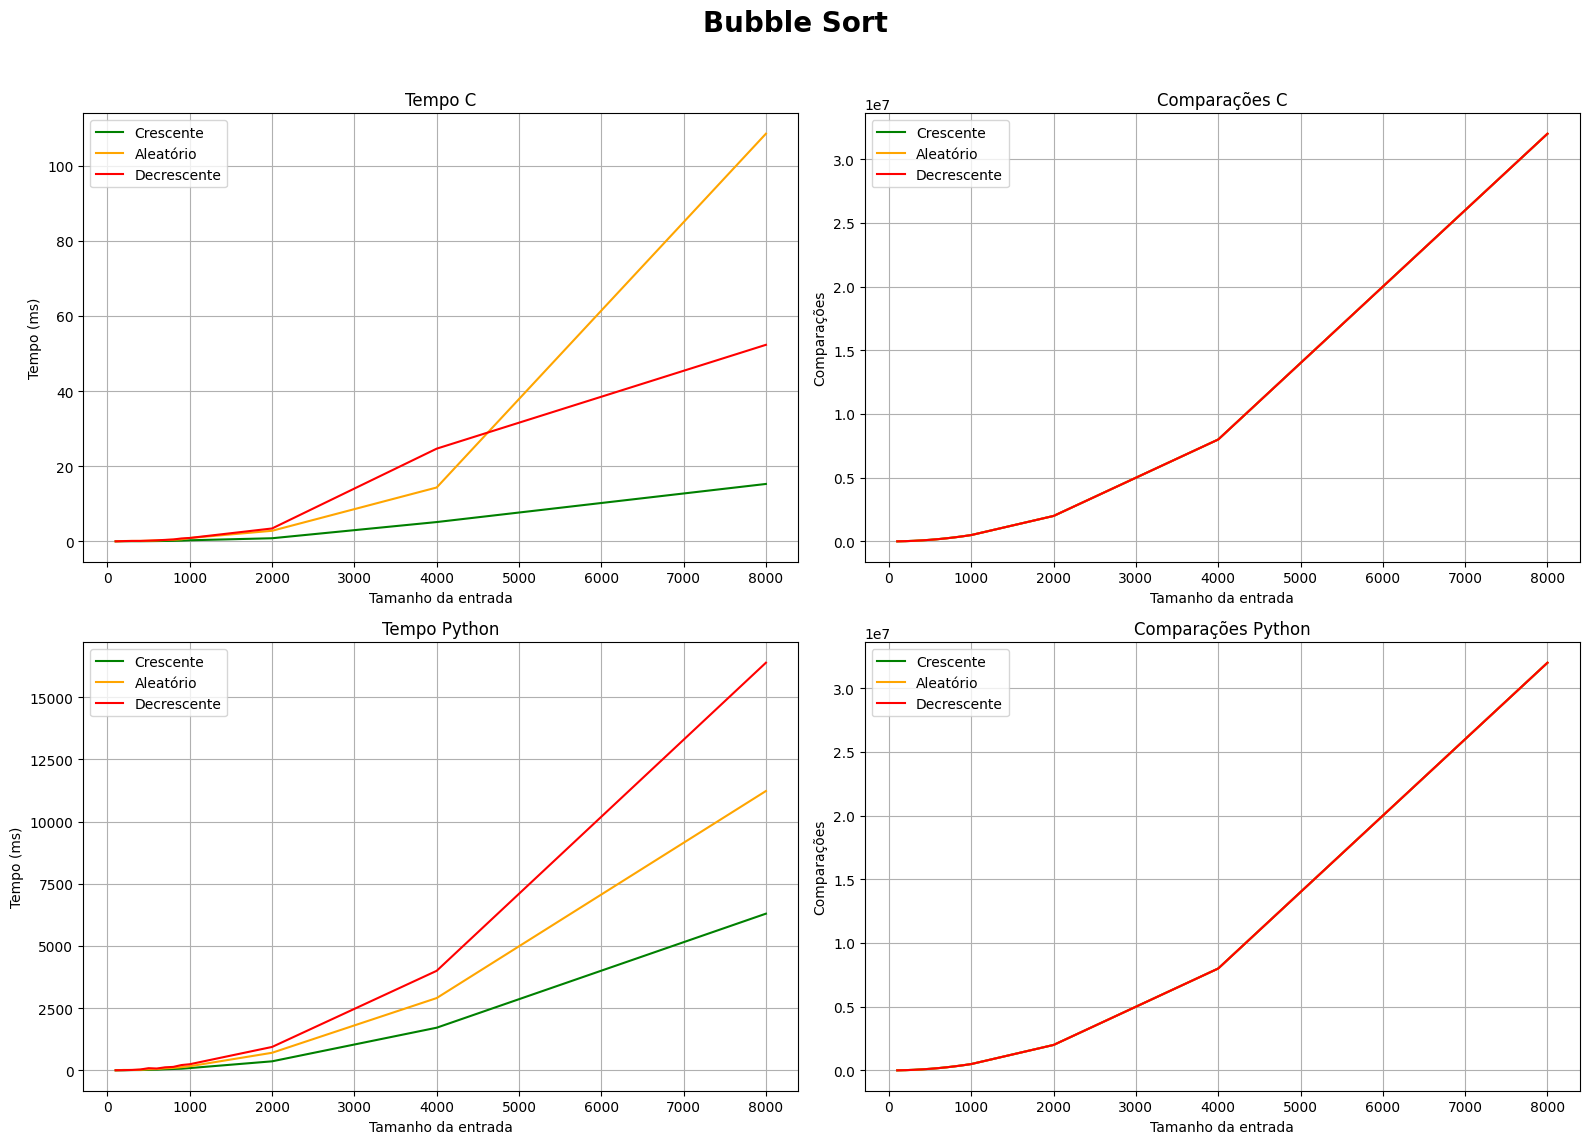

In [4]:
comparar_desempenho("Bubble Sort", run_c_bubble, py.bubble_sort, tamanhos=TAMANHOS)

### Selection Sort

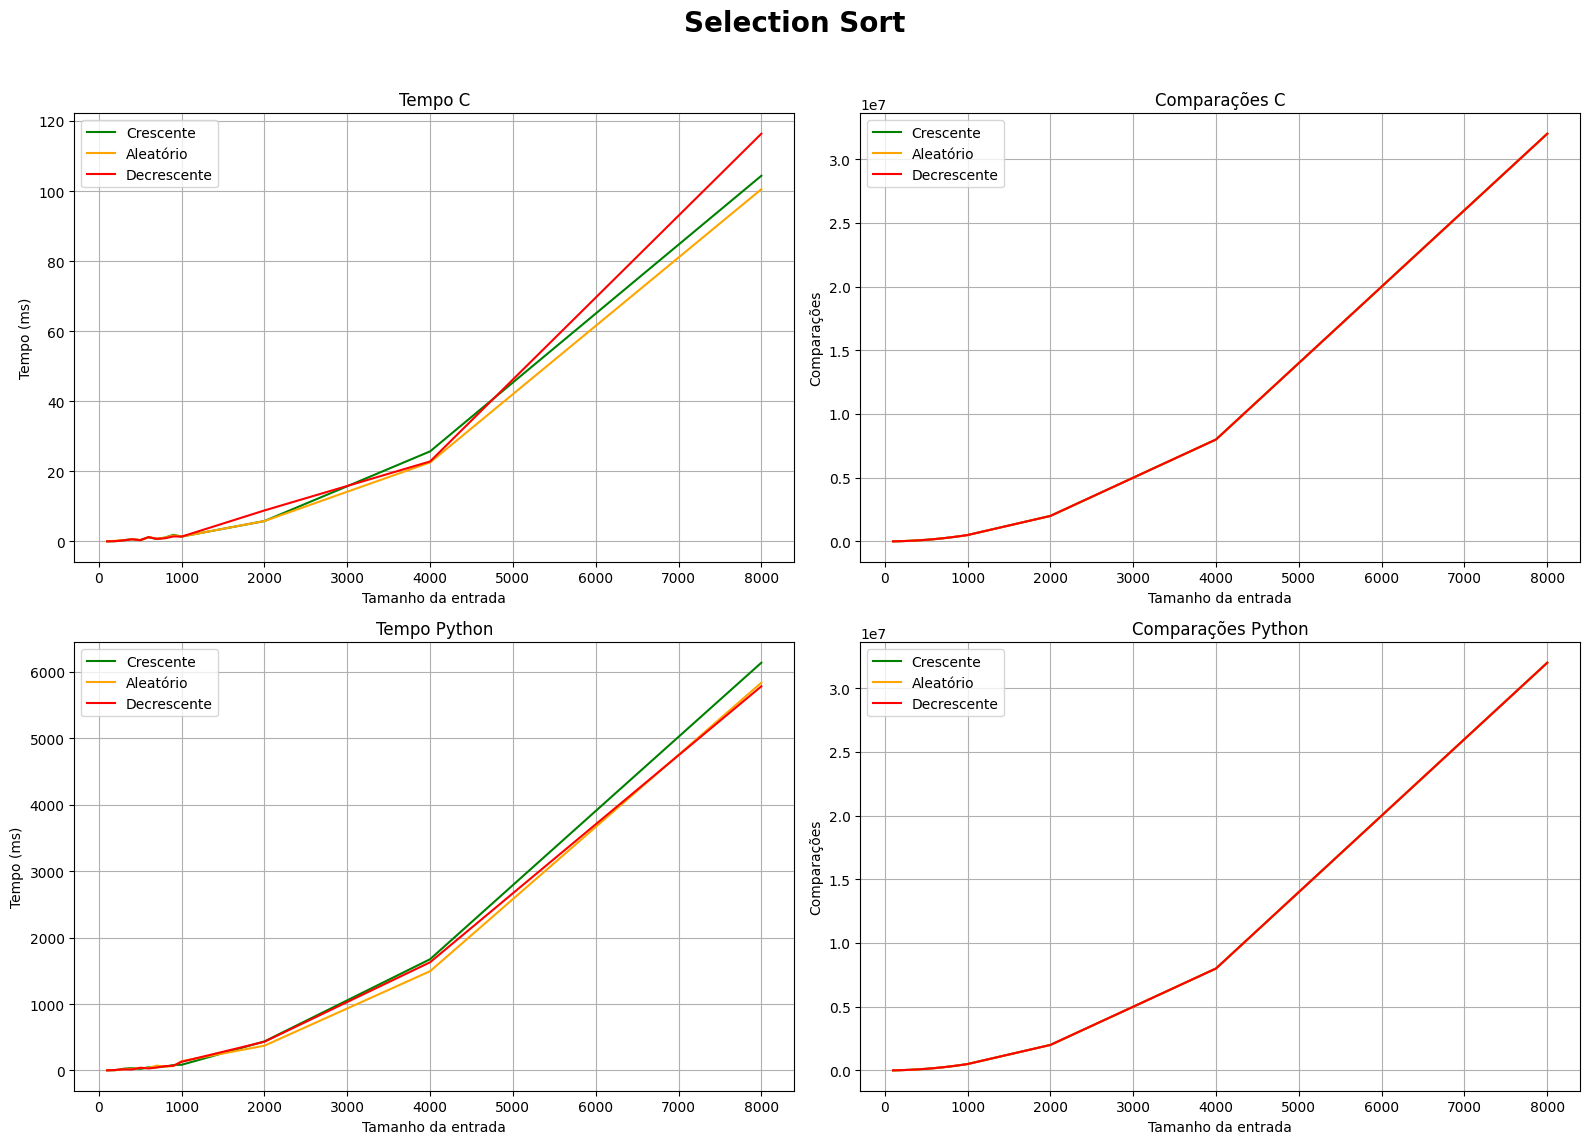

In [5]:
comparar_desempenho("Selection Sort", run_c_selection, py.selection_sort, tamanhos=TAMANHOS)

### Merge Sort

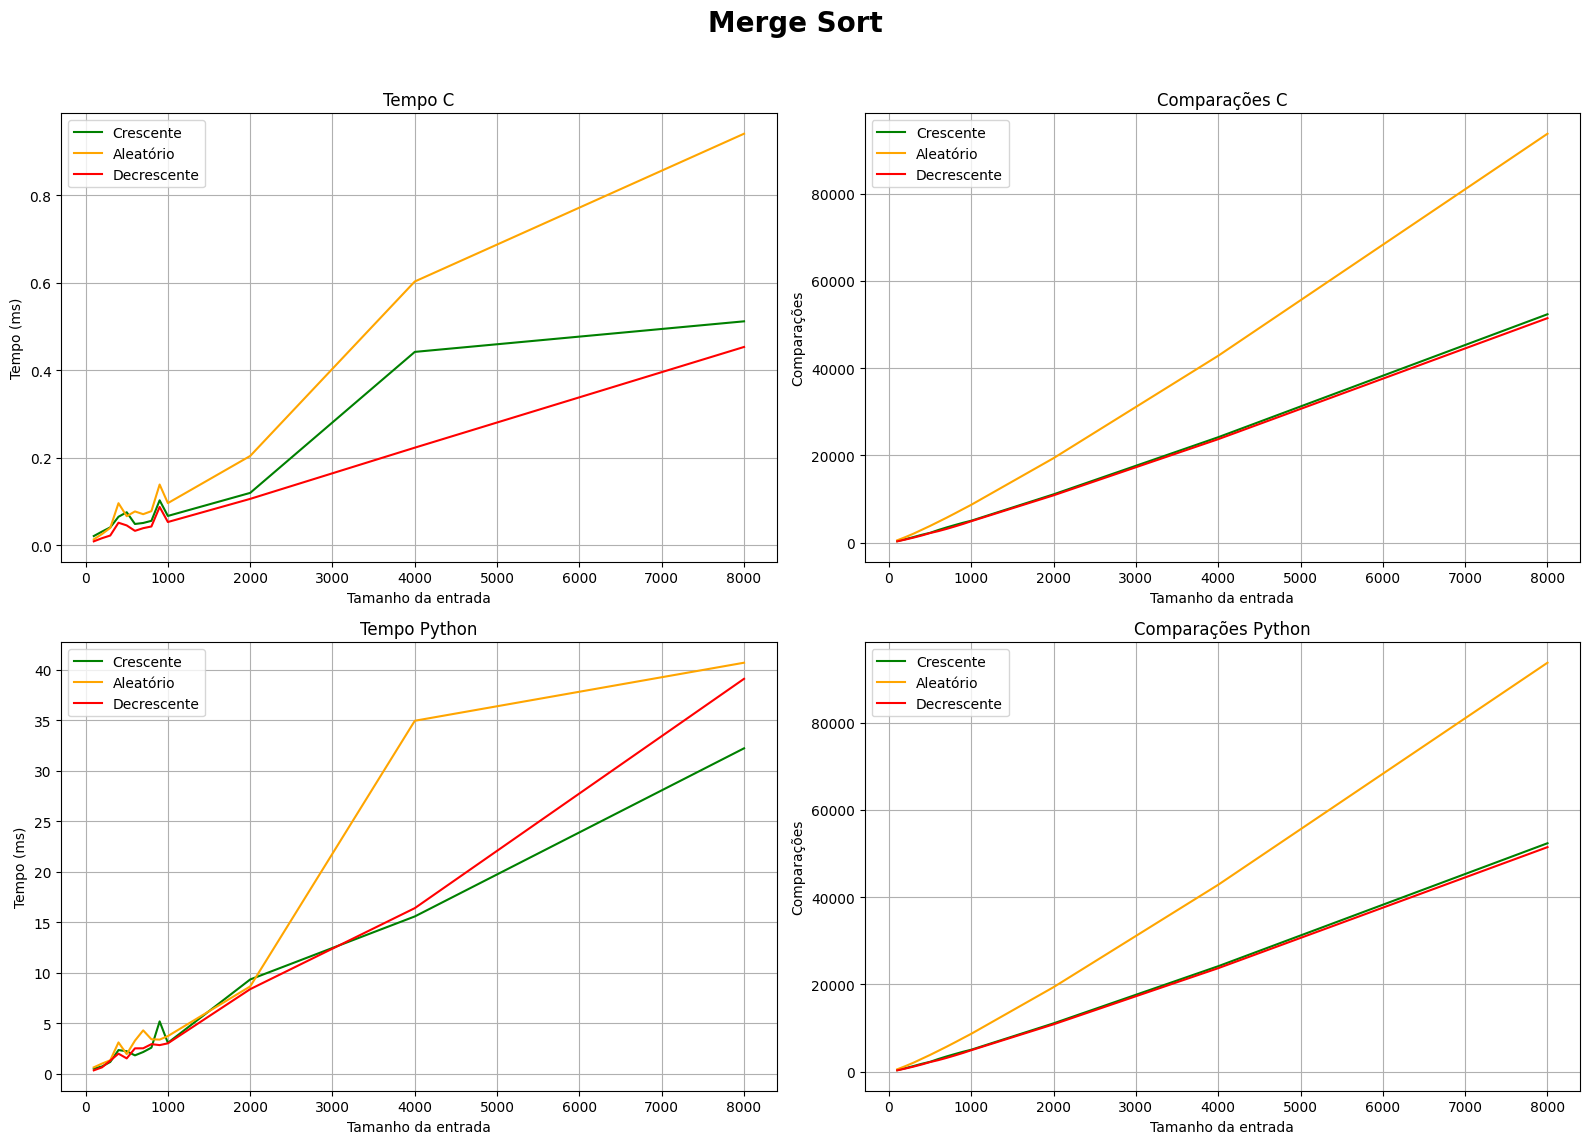

In [6]:
comparar_desempenho("Merge Sort", run_c_merge, py.merge_sort, tamanhos=TAMANHOS)

### Insertion Sort

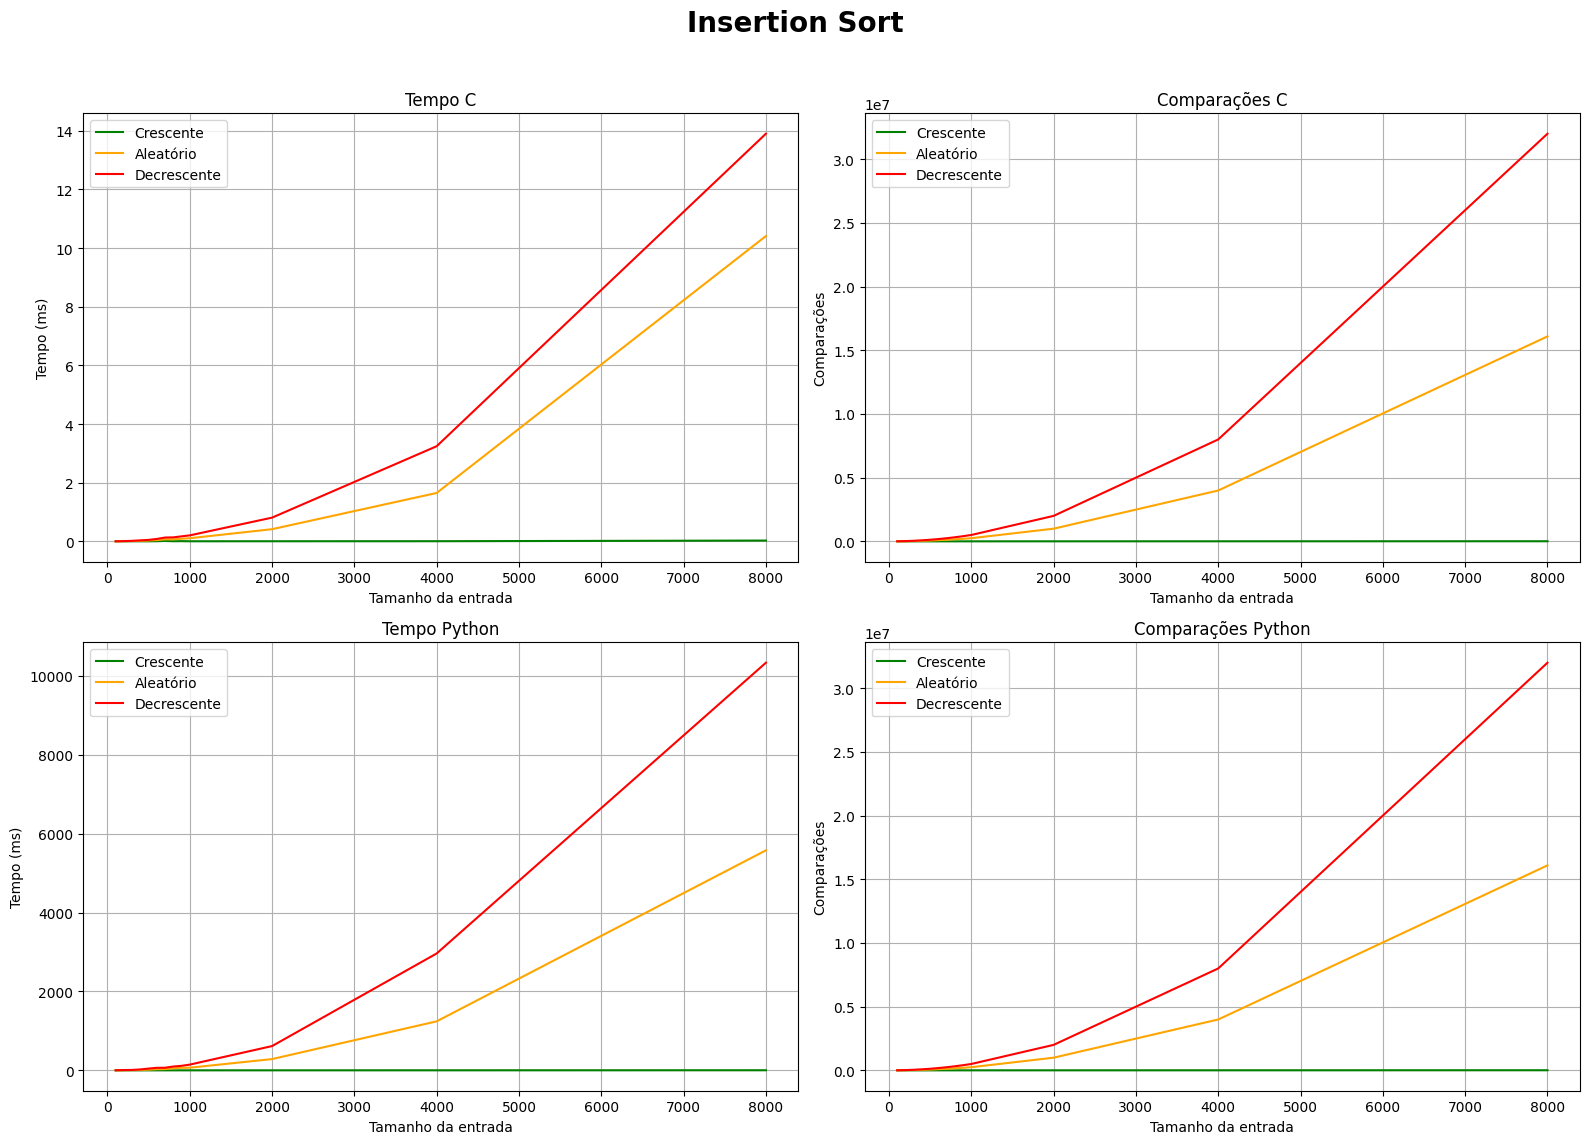

In [7]:
comparar_desempenho("Insertion Sort", run_c_insertion, py.insertion_sort, tamanhos=TAMANHOS)

### Quick Sort

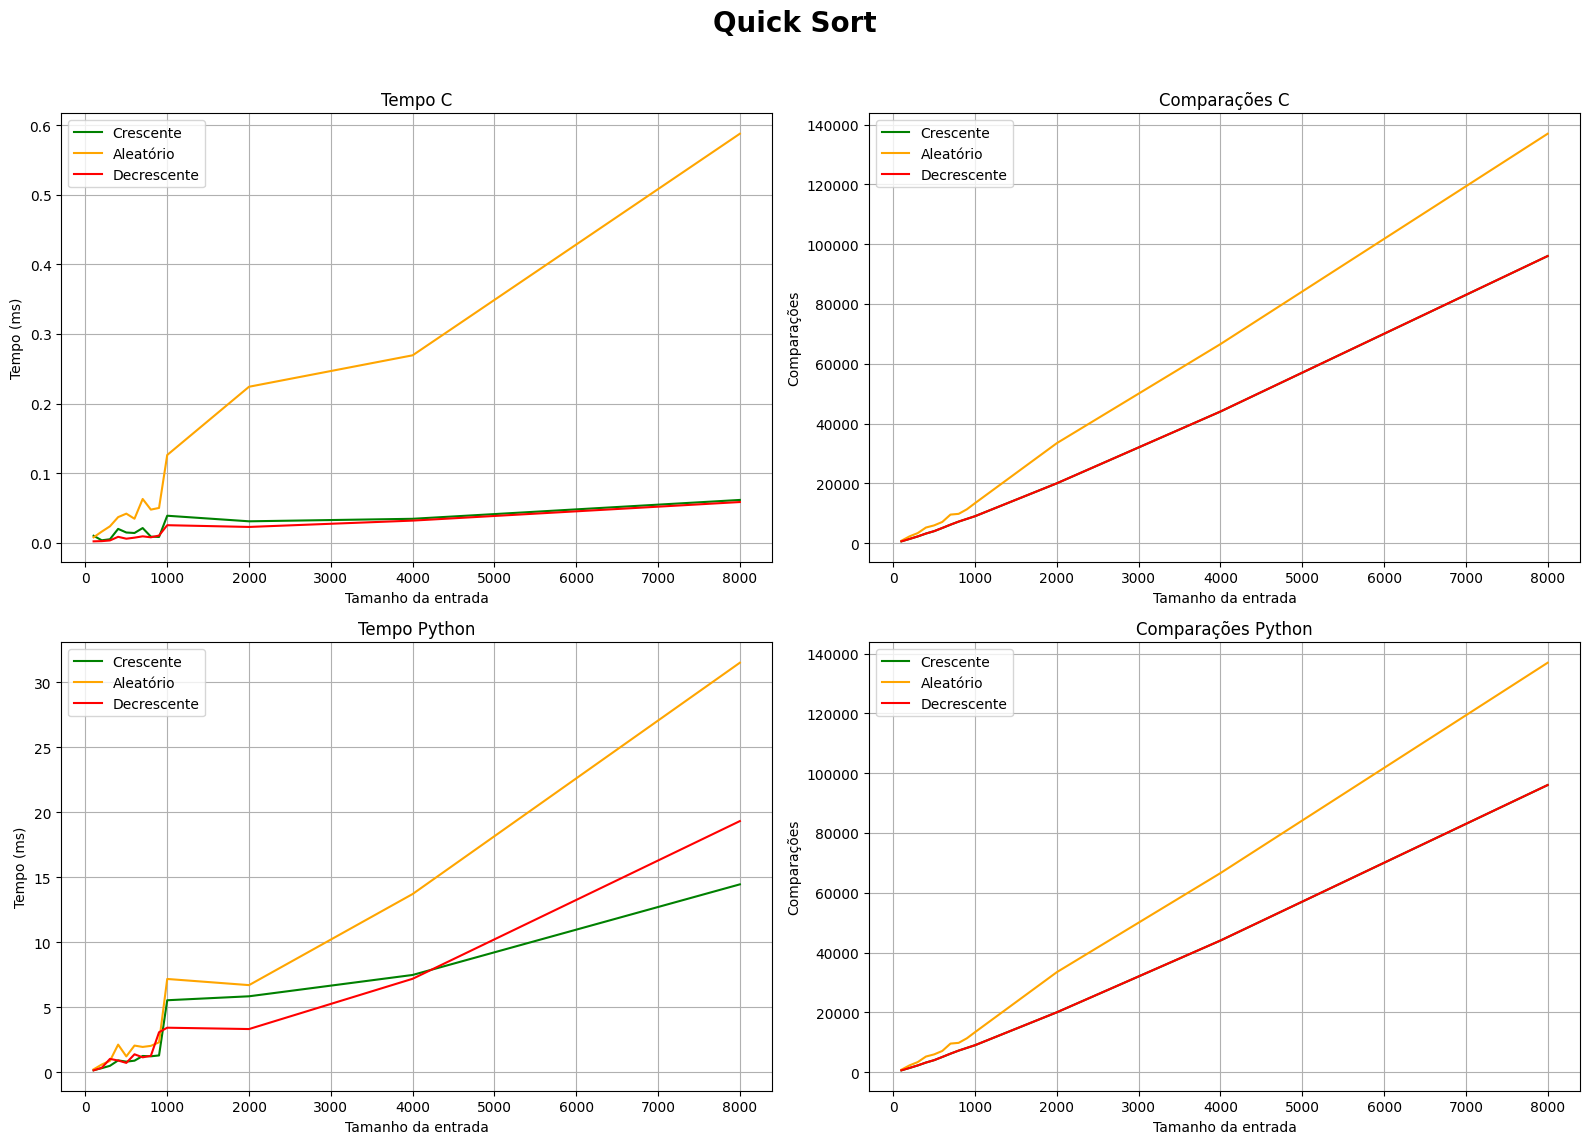

In [8]:
comparar_desempenho("Quick Sort", run_c_quick, py.quick_sort, tamanhos=TAMANHOS)